In [150]:
import json
from collections import defaultdict
from functools import reduce

import agama
import cmasher as cmr
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import utilities as ut
from astropy.stats import biweight_location
from matplotlib import cm
from matplotlib.animation import PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, zoom
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic_2d
from sklearn import cluster as cl
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


| Metric        | Meaning                                                                   |
| ------------- | ------------------------------------------------------------------------- |
| **Precision** | Of the predicted class instances, how many were correct? (TP / (TP + FP)) |
| **Recall**    | Of the actual class instances, how many were retrieved? (TP / (TP + FN))  |
| **F1-score**  | Harmonic mean of precision and recall. Good overall performance measure.  |
| **Support**   | Number of true instances for each class.                                  |


# Functions

In [151]:
def clustering(X, rnd_grps, n_clusters, cluster_type):
    scaler = StandardScaler()
    X_scal = scaler.fit_transform(X)

    if cluster_type == "kmeans":
        kmeans = cl.KMeans(n_clusters=n_clusters, random_state=0).fit(X_scal)
        labels = kmeans.labels_

    if cluster_type == "agglom":
        agglom = cl.AgglomerativeClustering(n_clusters=n_clusters).fit(X_scal)
        labels = agglom.labels_

    if cluster_type == "birch":
        birch = cl.Birch(n_clusters=n_clusters, threshold=0.2).fit(X_scal)
        labels = birch.labels_

    count = 0
    for label in range(n_clusters):
        label_msk = labels == label

        # Get group ID counts for accreted particles in this cluster
        grp_lst_acc = np.abs(rnd_grps[label_msk])
        unique_acc, counts_acc = np.unique(grp_lst_acc, return_counts=True)
        count_dict_acc = dict(zip(unique_acc, counts_acc))

        # Identify the most common group
        grp_identified = unique_acc[np.argmax(counts_acc)]

        if count_dict_acc[grp_identified] > count:
            count = count_dict_acc[grp_identified]
            grp_label = label
            pred_grp = grp_identified

    return pred_grp, grp_label, labels

In [152]:
def clustering_envelope(it, snap, proc_data, n_clusters, variables, cluster_type):
    it_id = gc_utils.iteration_name(it)
    snap_id = gc_utils.snapshot_name(snap)

    snp_dat = proc_data[it_id]["snapshots"][snap_id]
    acc_msk = snp_dat["now_accreted"][()] == 1
    bnd_msk = snp_dat["bound_flag"][()] == 1

    full_grps = np.abs(snp_dat["group_id"][acc_msk & bnd_msk])
    full_gcid = snp_dat["gc_id"][acc_msk & bnd_msk]

    rnd_grps = full_grps.copy()
    rnd_gcid = full_gcid.copy()

    unq_grp, cnt_grp = np.unique(full_grps, return_counts=True)
    grp_cnt_dict = dict(zip(unq_grp, cnt_grp))

    # res_dict = {
    #     gc_id: {"True": grp, "Pred": None} if grp in grp_lst else {"True": -1, "Pred": None}
    #     for gc_id, grp in zip(full_gcid, full_grps)
    # }

    # res_dict = {gc_id: {"True": grp, "Pred": None} for gc_id, grp in zip(full_gcid, full_grps)}

    res_dict = {
        gc_id: {"True": grp, "Pred": None} if grp_cnt_dict[grp] >= 5 else {"True": -1, "Pred": None}
        for gc_id, grp in zip(full_gcid, full_grps)
    }

    X_init = np.column_stack(
        [
            snp_dat["j.cyl"][:, 2][acc_msk & bnd_msk]
            if var == "jz"
            else snp_dat["j.cyl"][:, 1][acc_msk & bnd_msk]
            if var == "jp"
            else snp_dat["j.cyl"][:, 0][acc_msk & bnd_msk]
            if var == "jr"
            else snp_dat[var][acc_msk & bnd_msk]
            for var in variables
        ]
    )

    X = X_init

    while len(X) >= 5:
        pred_grp, grp_label, labels = clustering(X, rnd_grps, n_clusters, cluster_type)

        lab_msk = labels == grp_label
        gc_filt = rnd_gcid[lab_msk]

        for gc_id in gc_filt:
            res_dict[gc_id]["Pred"] = pred_grp

        rnd_grps = rnd_grps[~lab_msk]
        rnd_gcid = rnd_gcid[~lab_msk]
        X = X[~lab_msk]

    # group remaining gc's as other (-1)
    for gc_id in rnd_gcid:
        res_dict[gc_id]["Pred"] = -1

    return res_dict

In [153]:
def calc_entropy(p):
    """Compute Shannon entropy of a probability distribution p."""
    p = p[p > 0]  # filter out zeros to avoid log(0)
    return -np.sum(p * np.log2(p))


def clustering_entropy(true_labels, predicted_labels):
    labels = np.unique(np.concatenate((np.array(true_labels), np.array(predicted_labels))))
    cm = confusion_matrix(true_labels, predicted_labels, labels=labels)
    total = cm.sum()

    weighted_entropies = [] = []
    entropy_by_cluster = {}

    for i, col in enumerate(cm.T):  # loop over predicted clusters
        cluster_label = labels[i]
        cluster_total = np.sum(col)

        if cluster_total == 0:
            entropy_by_cluster[cluster_label] = 0.0
            weighted_entropies.append(0.0)
            continue

        p = col / cluster_total
        e = calc_entropy(p)
        weight = cluster_total / total

        entropy_by_cluster[cluster_label] = e / np.log2(cm.shape[1])
        weighted_entropies.append(weight * e)

    total_entropy = np.sum(weighted_entropies)

    # print(entropy_by_cluster)
    return total_entropy

In [154]:
# High F1 -> clear kinematic signature of a group (well-recovered).
# Low F1 -> the group is either mixed, fragmented, or indistinct.


def get_classifications(true_grp, pred_grp):
    report = classification_report(true_grp, pred_grp, output_dict=True, zero_division=0)

    class_dict = {}
    class_dict["macro_reca"] = report["macro avg"]["recall"]
    class_dict["macro_prec"] = report["macro avg"]["precision"]
    class_dict["macro_f1"] = report["macro avg"]["f1-score"]

    return report

In [155]:
def snapshot_clustering(it, proc_data, cluster_type, n_clusters, variables, snap_lst):
    snap_dict = {}
    snap_dict["entropy"] = []
    snap_dict["accuracy"] = []
    snap_dict["weight_recall"] = []
    snap_dict["macro_recall"] = []
    snap_dict["weight_precision"] = []
    snap_dict["macro_precision"] = []
    snap_dict["weight_f1"] = []
    snap_dict["macro_f1"] = []

    for snap in snap_lst:
        res_dict = clustering_envelope(it, snap, proc_data, n_clusters, variables, cluster_type)

        true_grp = [res_dict[gc_id]["True"] for gc_id in res_dict.keys()]
        pred_grp = [res_dict[gc_id]["Pred"] for gc_id in res_dict.keys()]

        entropy = clustering_entropy(true_grp, pred_grp)
        num_grps = len(np.unique(np.concatenate((true_grp, pred_grp))))
        entropy_norm = entropy / np.log2(num_grps)
        snap_dict["entropy"].append(entropy_norm)

        report = classification_report(true_grp, pred_grp, output_dict=True, zero_division=0)
        snap_dict["accuracy"].append(report["accuracy"])
        snap_dict["weight_recall"].append(report["weighted avg"]["recall"])
        snap_dict["macro_recall"].append(report["macro avg"]["recall"])
        snap_dict["weight_precision"].append(report["weighted avg"]["precision"])
        snap_dict["macro_precision"].append(report["macro avg"]["precision"])
        snap_dict["weight_f1"].append(report["weighted avg"]["f1-score"])
        snap_dict["macro_f1"].append(report["macro avg"]["f1-score"])

    return snap_dict

In [156]:
def iteration_clustering(it_lst, cluster_type, n_clusters, variables, sim, sim_dir, snap_lim):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    pub_data = sim_dir + "snapshot_times_public.txt"
    pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
    pub_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    snap_lst = pub_snaps["index"].values
    snap_lst = snap_lst[snap_lst >= snap_lim]
    time_lst = [pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0] for snap in snap_lst]

    # ent_it_lst = []
    it_dict = defaultdict(list)

    for it in it_lst:
        snap_dict = snapshot_clustering(it, proc_data, cluster_type, n_clusters, variables, snap_lst)
        for metric in snap_dict.keys():
            it_dict[metric].append(snap_dict[metric])

    cluster_dict = {
        "snap": snap_lst,
        "time": time_lst,
    }

    # Add mean and std of each metric across iterations
    for metric in it_dict.keys():
        cluster_dict[f"{metric}_avg"] = np.nanmean(it_dict[metric], axis=0)
        cluster_dict[f"{metric}_std"] = np.nanstd(it_dict[metric], axis=0)

    return cluster_dict

In [157]:
def averaged_metric(report, group_keys, metric="f1-score", exclude_group="0"):
    total_w_sum = 0.0
    total_m_sum = 0.0
    total_counts = 0

    num_grps = len(group_keys) - 1

    for group in group_keys:
        if group == exclude_group:
            continue

        value = report[group][metric]
        count = report[group]["support"]

        total_w_sum += value * count
        total_m_sum += value
        total_counts += count

    if total_counts == 0:
        w_avg = np.nan
        m_avg = np.nan
    else:
        w_avg = total_w_sum / total_counts
        m_avg = total_m_sum / num_grps

    return w_avg, m_avg

In [158]:
def group_snap_clustering(it, proc_data, cluster_type, n_clusters, variables, snap_lst):
    group_dict = {}
    for snap in snap_lst:
        res_dict = clustering_envelope(it, snap, proc_data, n_clusters, variables, cluster_type)

        true_grp = [res_dict[gc_id]["True"] for gc_id in res_dict.keys()]
        pred_grp = [res_dict[gc_id]["Pred"] for gc_id in res_dict.keys()]

        report = classification_report(true_grp, pred_grp, output_dict=True, zero_division=0)

        group_keys = [k for k in report.keys() if not any(c.isalpha() for c in str(k))]
        for group in group_keys:
            if group not in group_dict.keys():
                group_dict[group] = {"snap": [], "recall": [], "precision": [], "f1": []}

            group_dict[group]["snap"].append(snap)
            group_dict[group]["recall"].append(report[group]["recall"])
            group_dict[group]["precision"].append(report[group]["precision"])
            group_dict[group]["f1"].append(report[group]["f1-score"])

        if "ex_situ" not in group_dict.keys():
            group_dict["ex_situ"] = {
                "snap": [],
                "weight_recall": [],
                "macro_recall": [],
                "weight_precision": [],
                "macro_precision": [],
                "weight_f1": [],
                "macro_f1": [],
            }

        w_r, m_r = averaged_metric(report, group_keys, metric="recall")
        w_p, m_p = averaged_metric(report, group_keys, metric="precision")
        w_f, m_f = averaged_metric(report, group_keys, metric="f1-score")

        group_dict["ex_situ"]["snap"].append(snap)
        group_dict["ex_situ"]["weight_recall"].append(w_r)
        group_dict["ex_situ"]["macro_recall"].append(m_r)
        group_dict["ex_situ"]["weight_precision"].append(w_p)
        group_dict["ex_situ"]["macro_precision"].append(m_p)
        group_dict["ex_situ"]["weight_f1"].append(w_f)
        group_dict["ex_situ"]["macro_f1"].append(m_f)

    return group_dict

In [159]:
def group_iteration_clustering(it_lst, cluster_type, n_clusters, variables, sim, sim_dir, snap_lim):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    pub_data = sim_dir + "snapshot_times_public.txt"
    pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
    pub_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    snap_lst = pub_snaps["index"].values
    snap_lst = snap_lst[snap_lst >= snap_lim]
    time_lst = [pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0] for snap in snap_lst]

    # ent_it_lst = []
    # it_dict = defaultdict(list)
    it_dict = {}

    for it in it_lst:
        grp_snap_dict = group_snap_clustering(it, proc_data, cluster_type, n_clusters, variables, snap_lst)
        for key in grp_snap_dict.keys():
            if key not in it_dict:
                it_dict[key] = defaultdict(list)

            for metric in grp_snap_dict[key]:
                metric_lst = []
                for snap in snap_lst:
                    grp_snp_lst = np.array(grp_snap_dict[key]["snap"])
                    if snap not in grp_snp_lst:
                        metric_lst.append(np.nan)
                    else:
                        snp_msk = grp_snp_lst == snap
                        val = np.array(grp_snap_dict[key][metric])[snp_msk][0]
                        metric_lst.append(val)

                it_dict[key][metric].append(metric_lst)

    cluster_dict = {"snap": snap_lst, "time": time_lst, "groups": {}}

    # Add mean and std of each metric across iterations
    for key in it_dict.keys():
        if key == "ex_situ":
            cluster_dict[key] = {}
        else:
            cluster_dict["groups"][key] = {}
        for metric in it_dict[key].keys():
            if metric != "snap":
                if key == "ex_situ":
                    cluster_dict[key][f"{metric}_avg"] = np.nanmean(it_dict[key][metric], axis=0)
                    cluster_dict[key][f"{metric}_std"] = np.nanstd(it_dict[key][metric], axis=0)
                else:
                    cluster_dict["groups"][key][f"{metric}_avg"] = np.nanmean(it_dict[key][metric], axis=0)
                    cluster_dict["groups"][key][f"{metric}_std"] = np.nanstd(it_dict[key][metric], axis=0)

    cluster_dict["in_situ"] = {}
    for metric in cluster_dict["groups"]["0"].keys():
        cluster_dict["in_situ"][metric] = cluster_dict["groups"]["0"][metric]

    return cluster_dict

# Plotting

In [160]:
# sim = "m12m"
# group_id = 1920378
# disk_form = 4

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

snap_lim = 600  # m12i: 60, m12f:
cluster_type = "birch"

# variables = ["et", "jr", "jp", "jz"]
variables = ["et_norm", "jr", "jp", "jz"]
n_clusters = 2

agama.setUnits(mass=1, length=1, velocity=1)

# snap_lim = 46
# sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

# fire_dir = sim_dir + sim + "/" + sim + "_res7100"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

sim = "m12i"
all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

# proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
# proc_data = h5py.File(proc_file, "r")  # open processed data file

# grp_file = sim_dir + sim + "/" + "gc_groups.json"
# with open(grp_file, "r") as file:
#     grp_col_dict = json.load(file)

# grp_lst = [int(grp) for grp in grp_col_dict[sim].keys()]
# grp_lst

In [161]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
it_lst = np.arange(it_min, it_max + 1)

# for 101 iterations takes about 1 minute
# clsr_dict = iteration_clustering(it_lst, cluster_type, n_clusters, variables, sim, sim_dir, snap_lim)

# for 101 iterations takes about 1 minute
sim_clsr_dct = []
for sim in sim_lst:
    clsr_dct = group_iteration_clustering(it_lst, cluster_type, n_clusters, variables, sim, sim_dir, 600)
    sim_clsr_dct.append(clsr_dct)

In [162]:
grp_dict = []
for sim in sim_lst:
    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_col_dict = json.load(file)
    grp_lst = [int(grp) for grp in grp_col_dict[sim].keys() if int(grp) != 0]
    grp_dict.append(grp_lst)

In [163]:
def get_full(grp_lst, proc_data):
    grp_dict = {grp: {} for grp in grp_lst if grp != 0}

    for grp in grp_dict.keys():
        log_num_gc = []

        et_norm_avg = []
        et_norm_std = []
        jr_avg = []
        jr_std = []
        jp_avg = []
        jp_std = []
        jz_avg = []
        jz_std = []

        log_com_avg = []
        com_avg = []
        com_spd_avg = []
        com_spd_std = []  # small means uniform structure, large means possibly clumpy

        for it in range(it_min, it_max + 1):
            it_id = gc_utils.iteration_name(it)
            snp_600 = proc_data[it_id]["snapshots"]["snap600"]
            grp_msk = snp_600["group_id"][()] == grp

            # conserved quantities
            et_norm = snp_600["et_norm"][grp_msk]
            jcyl = snp_600["j.cyl"][grp_msk]
            jr = jcyl[:, 0]
            jp = jcyl[:, 1]
            jz = jcyl[:, 2]

            # CoM
            xyz = snp_600["pos.xyz"][grp_msk]
            mass = 10 ** snp_600["mass"][grp_msk]

            c_x = np.sum(xyz[:, 0] * mass) / np.sum(mass)
            c_y = np.sum(xyz[:, 1] * mass) / np.sum(mass)
            c_z = np.sum(xyz[:, 2] * mass) / np.sum(mass)

            com = np.array([c_x, c_y, c_z])
            com_d = np.linalg.norm(com)

            # d_c = np.sqrt((c_x - xyz[:, 0]) ** 2 + (c_y - xyz[:, 1]) ** 2 + (c_z - xyz[:, 2]) ** 2)
            d_c = []
            for pos in xyz:
                d_c.append(ut.coordinate.get_distances(com, pos, total_distance=True))

            # append lists
            num_gc = len(et_norm)
            if num_gc == 0:
                continue

            log_num_gc.append(np.log10(num_gc))  # logged

            et_norm_avg.append(np.mean(et_norm))
            et_norm_std.append(np.std(et_norm))

            jr_avg.append(np.mean(np.log10(jr)))  # logged
            jr_std.append(np.std(np.log10(jr)))  # logged
            jp_avg.append(np.mean(jp))
            jp_std.append(np.std(jp))
            jz_avg.append(np.mean(np.log10(jz)))  # logged
            jz_std.append(np.std(np.log10(jz)))  # logged

            com_avg.append(com_d)
            com_spd_avg.append(np.mean(d_c))
            com_spd_std.append(np.std(d_c))

        weigh = 10 ** np.array(log_num_gc)

        grp_dict[grp]["log_num_gc"] = np.nanmean(log_num_gc)

        grp_dict[grp]["et_norm_avg"] = np.sum(weigh * np.array(et_norm_avg)) / np.sum(weigh)
        grp_dict[grp]["et_norm_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(et_norm_std) ** 2) / np.sum(weigh - 1)
        )

        grp_dict[grp]["log_jr_avg"] = np.sum(weigh * np.array(jr_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jr_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jr_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["jp_avg"] = np.sum(weigh * np.array(jp_avg)) / np.sum(weigh)
        grp_dict[grp]["jp_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jp_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["log_jz_avg"] = np.sum(weigh * np.array(jz_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jz_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jz_std) ** 2) / np.sum(weigh - 1))

        grp_dict[grp]["com_avg"] = np.sum(weigh * np.array(com_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_avg"] = np.sum(weigh * np.array(com_spd_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(com_spd_std) ** 2) / np.sum(weigh - 1)
        )

        grp_dict[grp]["log_com_avg"] = np.log10(grp_dict[grp]["com_avg"])

    return grp_dict

In [ ]:
def get_recall(grp_lst, proc_data, clsr_dct_grp):
    scaler = StandardScaler()

    grp_dict = {grp: {} for grp in grp_lst if grp != 0}

    for grp in grp_dict.keys():
        log_num_gc = []

        et_norm_avg = []
        et_norm_std = []
        jr_avg = []
        jr_std = []
        jp_avg = []
        jp_std = []
        jz_avg = []
        jz_std = []

        com_avg = []
        com_spd_avg = []
        com_spd_std = []  # small means uniform structure, large means possibly clumpy

        recall = clsr_dct_grp["groups"][str(grp)]["recall_avg"][-1]

        for it in range(it_min, it_max + 1):
            it_id = gc_utils.iteration_name(it)
            snp_dat = proc_data[it_id]["snapshots"]["snap600"]
            grp_msk = snp_dat["group_id"][()] == grp

            gcid_full = snp_dat["gc_id"][()]
            grp_gcid = snp_dat["gc_id"][grp_msk]
            nongrp_gcid = snp_dat["gc_id"][~grp_msk]

            grp_num = np.sum(grp_msk)
            grp_num_recall = int(np.round(grp_num * recall))

            if grp_num == 0:
                continue

            # grp stuff ############################################
            X_grp = np.column_stack(
                [
                    snp_dat["j.cyl"][:, 2][grp_msk]
                    if var == "jz"
                    else snp_dat["j.cyl"][:, 1][grp_msk]
                    if var == "jp"
                    else snp_dat["j.cyl"][:, 0][grp_msk]
                    if var == "jr"
                    else snp_dat[var][grp_msk]
                    for var in variables
                ]
            )

            X_grp_scal = scaler.fit_transform(X_grp)

            centroid = X_grp_scal.mean(axis=0)

            grp_scores = np.linalg.norm((X_grp_scal - centroid), axis=1)
            sml_idx = np.argsort(grp_scores)[:grp_num_recall]
            gcid_grp_proc = grp_gcid[sml_idx]

            X_nongrp = np.column_stack(
                [
                    snp_dat["j.cyl"][:, 2][~grp_msk]
                    if var == "jz"
                    else snp_dat["j.cyl"][:, 1][~grp_msk]
                    if var == "jp"
                    else snp_dat["j.cyl"][:, 0][~grp_msk]
                    if var == "jr"
                    else snp_dat[var][~grp_msk]
                    for var in variables
                ]
            )

            X_nongrp_scal = scaler.fit_transform(X_nongrp)
            nongrp_scores = np.linalg.norm((X_nongrp_scal - centroid), axis=1)
            sml_idx = np.argsort(nongrp_scores)[: grp_num - grp_num_recall]
            gcid_grp_proc = np.concatenate((gcid_grp_proc, nongrp_gcid[sml_idx]))

            gcid_mask = np.isin(gcid_full, gcid_grp_proc)

            # conserved quantities
            et_norm = snp_dat["et_norm"][gcid_mask]
            jcyl = snp_dat["j.cyl"][gcid_mask]
            jr = jcyl[:, 0]
            jp = jcyl[:, 1]
            jz = jcyl[:, 2]

            # CoM
            xyz = snp_dat["pos.xyz"][gcid_mask]
            mass = 10 ** snp_dat["mass"][gcid_mask]

            c_x = np.sum(xyz[:, 0] * mass) / np.sum(mass)
            c_y = np.sum(xyz[:, 1] * mass) / np.sum(mass)
            c_z = np.sum(xyz[:, 2] * mass) / np.sum(mass)

            com = np.array([c_x, c_y, c_z])
            com_d = np.linalg.norm(com)

            d_c = []
            for pos in xyz:
                d_c.append(ut.coordinate.get_distances(com, pos, total_distance=True))

            # append lists
            num_gc = len(et_norm)
            if num_gc == 0:
                continue

            log_num_gc.append(np.log10(num_gc))  # logged

            et_norm_avg.append(np.mean(et_norm))
            et_norm_std.append(np.std(et_norm))

            jr_avg.append(np.mean(np.log10(jr)))  # logged
            jr_std.append(np.std(np.log10(jr)))  # logged
            jp_avg.append(np.mean(jp))
            jp_std.append(np.std(jp))
            jz_avg.append(np.mean(np.log10(jz)))  # logged
            jz_std.append(np.std(np.log10(jz)))  # logged

            com_avg.append(com_d)
            com_spd_avg.append(np.mean(d_c))
            com_spd_std.append(np.std(d_c))

        weigh = 10 ** np.array(log_num_gc)

        grp_dict[grp]["log_num_gc"] = np.nanmean(log_num_gc)

        grp_dict[grp]["et_norm_avg"] = np.sum(weigh * np.array(et_norm_avg)) / np.sum(weigh)
        grp_dict[grp]["et_norm_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(et_norm_std) ** 2) / np.sum(weigh - 1)
        )

        grp_dict[grp]["log_jr_avg"] = np.sum(weigh * np.array(jr_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jr_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jr_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["jp_avg"] = np.sum(weigh * np.array(jp_avg)) / np.sum(weigh)
        grp_dict[grp]["jp_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jp_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["log_jz_avg"] = np.sum(weigh * np.array(jz_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jz_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jz_std) ** 2) / np.sum(weigh - 1))

        grp_dict[grp]["com_avg"] = np.sum(weigh * np.array(com_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_avg"] = np.sum(weigh * np.array(com_spd_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(com_spd_std) ** 2) / np.sum(weigh - 1)
        )

    return grp_dict

In [165]:
grp_prop_dict = []
for i, sim in enumerate(sim_lst):
    grp_lst = grp_dict[i]
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    hold_dict = get_full(grp_lst, proc_data)
    grp_prop_dict.append(hold_dict)

    proc_data.close()

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_16590/848761138.py:37: RuntimeWarning: invalid value encountered in scalar divide
  c_x = np.sum(xyz[:, 0] * mass) / np.sum(mass)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_16590/848761138.py:38: RuntimeWarning: invalid value encountered in scalar divide
  c_y = np.sum(xyz[:, 1] * mass) / np.sum(mass)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_16590/848761138.py:39: RuntimeWarning: invalid value encountered in scalar divide
  c_z = np.sum(xyz[:, 2] * mass) / np.sum(mass)


In [166]:
grp_prop_dict_rec = []
for i, sim in enumerate(sim_lst):
    grp_lst = grp_dict[i]
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    clsr_dct = sim_clsr_dct[i]

    hold_dict = get_recall(grp_lst, proc_data, clsr_dct)
    grp_prop_dict_rec.append(hold_dict)

    proc_data.close()

In [167]:
gc_prop_lst = [
    "log_num_gc",
    "et_norm_avg",
    "et_norm_std",
    "log_jr_avg",
    "log_jr_std",
    "jp_avg",
    "jp_std",
    "log_jz_avg",
    "log_jz_std",
    "com_avg",
    "log_com_avg",
    "com_spd_avg",
    "com_spd_std",
]

gal_prop_lst = [
    "t_quench",  # time galaxy made all its starts
    "t_quench_dis",  # time prior to t_dis galaxy made all its starts
    "t_quench_sat",  # time prior to t_dis galaxy made all its starts
    "t_sat",  # time galaxy first became a satellite
    "t_dis",  # time galaxy was no longer identified in halo finder
    "t_sat_t_dis",  # t_dis - t_sat
    "log_m_halo_sat",  # halo mass of galaxy when first became satellite
    "log_m_star_sat",  # stellar mass of galaxy when first became satellite
    "lx_sat",  # lx of galaxy when first became satellite
    "ly_sat",  # ly of galaxy when first became satellite
    "lz_sat",  # lz of galaxy when first became satellite
    "ltot_sat",  # l_tot of galaxy when first became satellite
    "log_ltot_sat",  # l_tot of galaxy when first became satellite
    "vel_circ_max_sat",  # max circular velocity of galaxy when first became satellite
    "log_vel_circ_max_sat",  # log of max circular velocity of galaxy when first became satellite
    "inc_sat",  # inclination of galaxy when first became satellite
]

gal_prop_dict = []
for i, _ in enumerate(grp_dict):
    grp_lst = grp_dict[i]
    gal_dict = {grp: {prop_str: {} for prop_str in gal_prop_lst} for grp in grp_lst if grp != 0}
    gal_prop_dict.append(gal_dict)

In [168]:
# grp_lst_non0 = [grp for grp in grp_lst if grp != 0]


def gal_data(grp_lst_non0, hals, halt, gal_dict):
    for grp in grp_lst_non0:
        ###########################################
        tidx = np.where(halt["tid"] == grp)[0][0]
        pre_dis_snp = halt["snapshot"][tidx]

        cidx = halt["catalog.index"][tidx]

        # t_dis
        t_dis = all_snaps[all_snaps["index"] == pre_dis_snp + 1]["time_Gyr"].values[0]

        # t_qunch and t_quench_dis
        t_form_100 = 0
        for snap in range(50, pre_dis_snp):
            snp_tid = gc_utils.get_halo_prog_at_snap(halt, grp, snap)
            snp_tidx = np.where(halt["tid"] == snp_tid)[0][0]

            # t_form_100_hold = halt["star.form.time.100"][snp_tidx]
            t_form_100_hold = hals[pre_dis_snp]["star.form.time.100"][cidx]
            t_form_100 = np.max((t_form_100, t_form_100_hold))

        t_quench = t_form_100
        t_quench_dis = t_dis - t_quench

        # t_sat, t_quench_sat
        sat_snp = hals[pre_dis_snp]["infall.first.snapshot"][cidx]
        t_sat = all_snaps[all_snaps["index"] == sat_snp]["time_Gyr"].values[0]

        t_quench_sat = t_sat - t_quench

        # t_sat_t_dis
        t_sat_t_dis = t_dis - t_sat

        # m_halo_sat, m_star_sat
        sat_tid = gc_utils.get_halo_prog_at_snap(halt, grp, sat_snp)
        sat_tidx = np.where(halt["tid"] == sat_tid)[0][0]
        sat_cidx = halt["catalog.index"][sat_tidx]

        m_halo_sat = halt["mass"][sat_tidx]
        log_m_halo_sat = np.log10(m_halo_sat)

        # m_star_sat = halt["star.mass"][sat_tidx]
        m_star_sat = hals[sat_snp]["star.mass"][sat_cidx]
        log_m_star_sat = np.log10(m_star_sat)

        # vel_circ_max_sat
        vel_circ_max_sat = halt["vel.circ.max"][sat_tidx]
        log_vel_circ_max_sat = np.log10(vel_circ_max_sat)

        # lx_sat, ly_sat, lz_sat, ltot_sat
        sat_pos_xyz = halt.prop("host.distance")[sat_tidx]
        sat_vel_xyz = halt.prop("host.velocity")[sat_tidx]

        lx_sat = sat_pos_xyz[1] * sat_vel_xyz[2] - sat_pos_xyz[2] * sat_vel_xyz[1]
        ly_sat = sat_pos_xyz[2] * sat_vel_xyz[0] - sat_pos_xyz[0] * sat_vel_xyz[2]
        lz_sat = sat_pos_xyz[0] * sat_vel_xyz[1] - sat_pos_xyz[1] * sat_vel_xyz[0]

        ltot_sat = np.linalg.norm([lx_sat, ly_sat, lz_sat])
        log_ltot_sat = np.log10(ltot_sat)

        # inc_sat
        inc_sat = np.degrees(np.arccos(lz_sat / ltot_sat))

        # add to dictionary
        for prop_str in gal_dict[grp].keys():
            prop = locals()[prop_str]
            gal_dict[grp][prop_str] = prop

    return gal_dict

In [169]:
for i, _ in enumerate(gal_prop_dict):
    sim = sim_lst[i]
    gal_prop = gal_prop_dict[i]
    # grp_prop = grp_prop_dict[i]

    grp_lst_non0 = grp_dict[i]

    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    halt = gc_utils.get_halo_tree(sim, sim_dir, assign_hosts_rotation=True)

    hals_snp_lst = np.arange(10, 601)
    hals = halo.io.IO.read_catalogs("index", hals_snp_lst, fire_dir)

    gal_prop_dict[i] = gal_data(grp_lst_non0, hals, halt, gal_prop)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:17<00:00, 77.43s/it]


In [232]:
def plotting(ax, grp_dict, gal_dict, title, i=0):
    consider_pvalue = True
    pvalue_limit = 0.05
    pre_disk_cut = False
    # disk_form = 6

    num_rows = len(gal_prop_lst)
    num_cols = len(gc_prop_lst)

    cor_arr = np.zeros(shape=(num_rows, num_cols))

    for j, gal_prop in enumerate(gal_prop_lst):
        for i, gc_prop in enumerate(gc_prop_lst):
            gal_lst = []
            gc_lst = []
            for grp in grp_dict.keys():
                # if (pre_disk_cut) & (gal_dict[grp]["t_dis"] <= disk_form):
                #     continue
                prop_hold = grp_dict[grp][gc_prop]
                if np.isnan(prop_hold):
                    continue
                else:
                    gc_lst.append(prop_hold)
                    gal_lst.append(gal_dict[grp][gal_prop])

            p_stats = stats.pearsonr(gc_lst, gal_lst)
            cor_arr[j, i] = p_stats.statistic

            if (consider_pvalue) & (p_stats.pvalue > pvalue_limit):
                cor_arr[j, i] = np.nan

    ########################################
    sig_lim = 0.9

    # plt.figure(figsize=(12, 10))
    im = ax.imshow(cor_arr, vmin=-1, vmax=1, cmap="seismic")
    # plt.colorbar(label="Pearson Correlation")

    if i == 1:
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Pearson Correlation")

    ax.set_xticks(np.arange(0, len(gc_prop_lst)), gc_prop_lst, rotation=45, ha="right")
    ax.set_yticks(np.arange(0, len(gal_prop_lst)), gal_prop_lst, rotation=45, ha="right")

    for j, gal_prop in enumerate(gal_prop_lst):
        for i, gc_prop in enumerate(gc_prop_lst):
            if np.abs(cor_arr[j, i]) >= sig_lim:
                ax.scatter(i, j, c="w", s=50)

    ax.set_title(title)

In [233]:
gal_dict_merged = reduce(lambda x, y: x | y, gal_prop_dict)
grp_dict_merged = reduce(lambda x, y: x | y, grp_prop_dict)
grp_dict_rec_merged = reduce(lambda x, y: x | y, grp_prop_dict_rec)

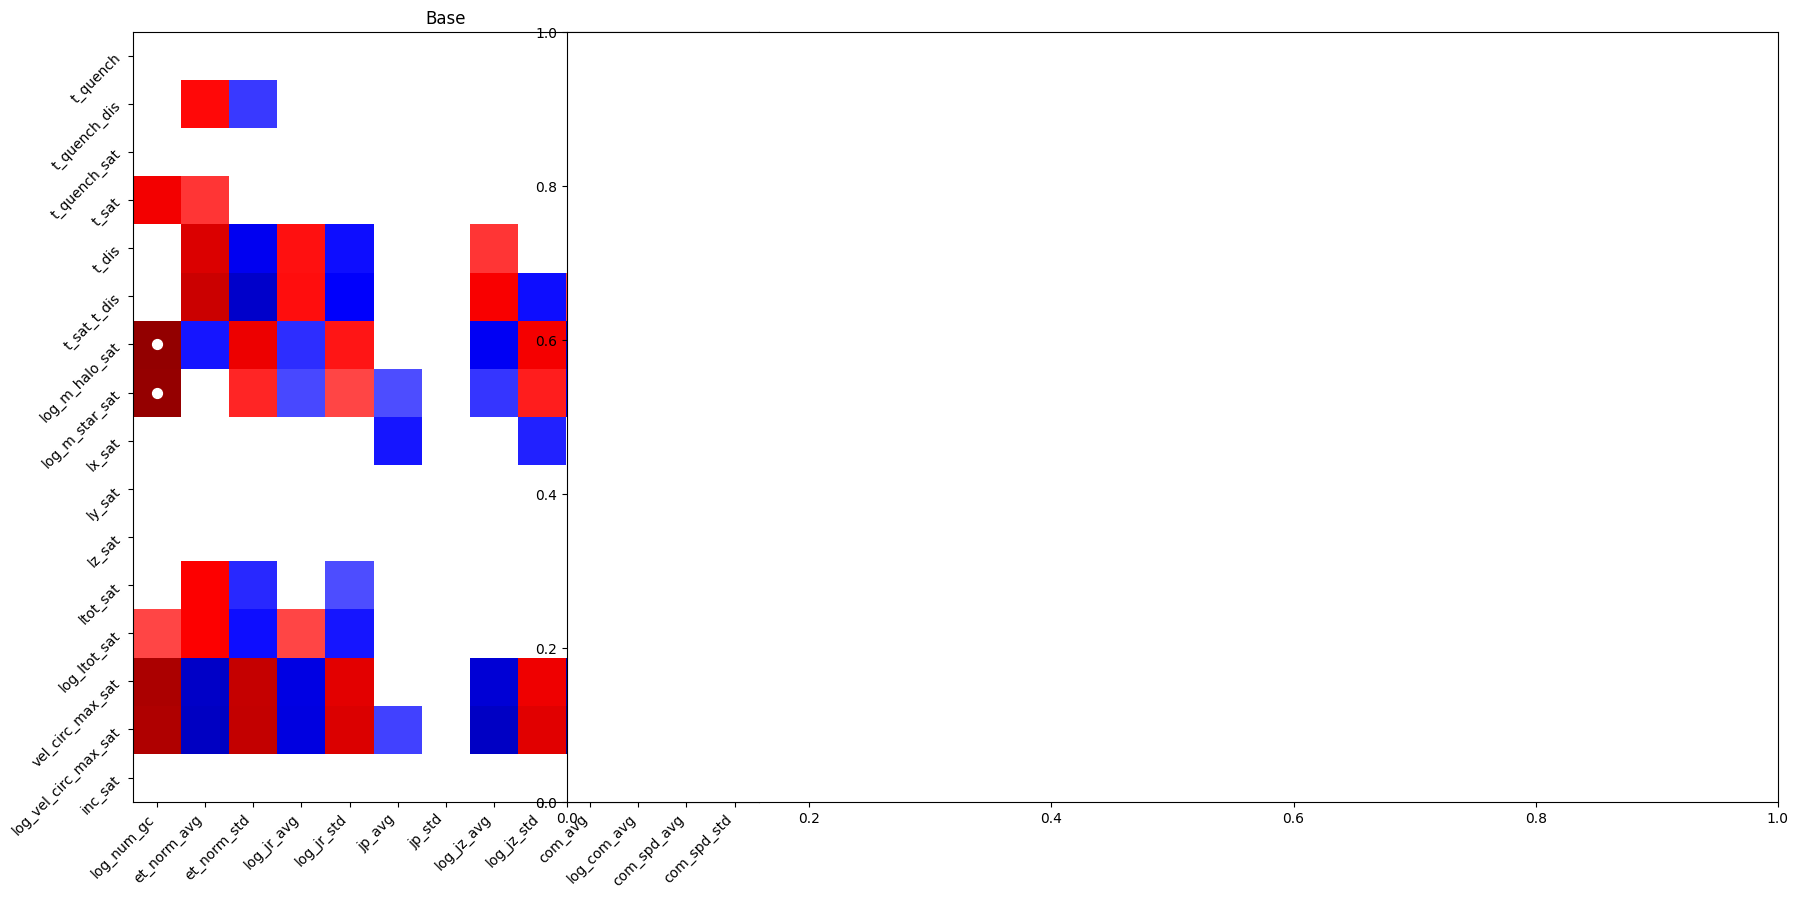

In [235]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10), sharey=False, sharex=False)
plt.subplots_adjust(wspace=-0.4)

plotting(axs[0], grp_dict_merged, gal_dict_merged, "Base")
# plotting(axs[1], grp_dict_rec_merged, gal_dict_merged, "Contaminated")

# plotting(ax, grp_dict, gal_dict, title)

In [188]:
gal_ex_lst = [
    "t_quench",
    "t_quench_dis",
    "t_quench_sat",
    "t_sat",
    "t_dis",
    "t_sat_t_dis",
    "log_vel_circ_max_sat",
    "log_ltot_sat",
]

grp_ex_lst = ["com_spd_std", "com_avg"]


In [221]:
grp_labels = [
    r"$\overline{\text{log}N_{\text{GC}}}$",
    r"$\overline{\text{e}}$",
    r"$\sigma_{\text{e}}$",
    r"$\overline{\text{log J}_{r}}$",
    r"$\sigma_{\text{log J}_{r}}$",
    r"$\overline{J_{\phi}}$",
    r"$\sigma_{J_{\phi}}$",
    r"$\overline{\text{log J}_{z}}$",
    r"$\sigma_{\text{log J}_{z}}$",
    r"$\overline{\text{log }r_{\text{CoM}}}$",
    r"$\overline{r_\text{sub}}$",
]

gal_labels = [
    r"$\text{log }M_{\text{halo}}$",
    r"$\text{log }M_{\text{star}}$",
    r"$\text{l}_{\text{x}}$",
    r"$\text{l}_{\text{y}}$",
    r"$\text{l}_{\text{z}}$",
    r"$\text{l}_{\text{total}}$",
    r"$\text{V}_{\text{circ, max}}$",
    r"$i$",
]

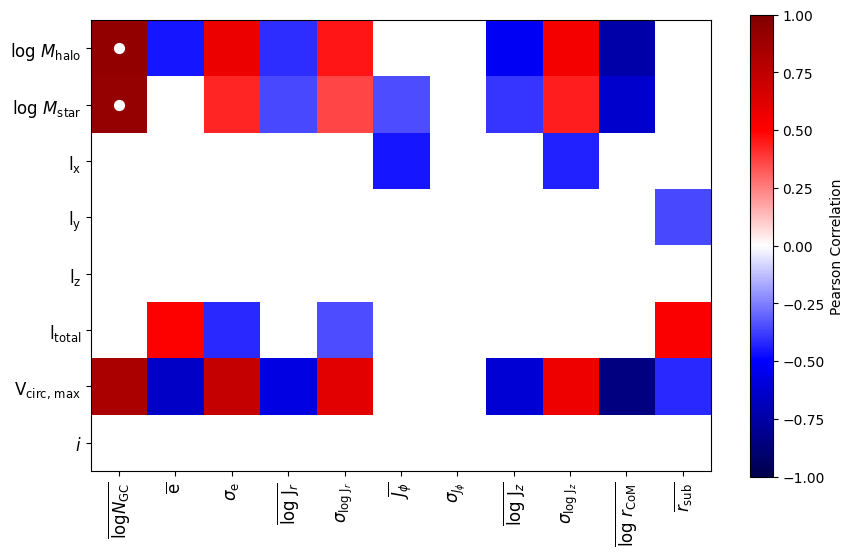

In [236]:
gal_dict = gal_dict_merged
grp_dict = grp_dict_merged

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharey=False, sharex=False)

consider_pvalue = True
pvalue_limit = 0.05

gal_prop_lst_rev = [gal_prop for gal_prop in gal_prop_lst if gal_prop not in gal_ex_lst]
grp_prop_lst_rev = [grp_prop for grp_prop in gc_prop_lst if grp_prop not in grp_ex_lst]

# gal_prop_lst_rev = gal_prop_lst
# grp_prop_lst_rev = gc_prop_lst

num_rows = len(gal_prop_lst_rev)
num_cols = len(grp_prop_lst_rev)

cor_arr = np.zeros(shape=(num_rows, num_cols))

for j, gal_prop in enumerate(gal_prop_lst_rev):
    for i, gc_prop in enumerate(grp_prop_lst_rev):
        gal_lst = []
        gc_lst = []
        for grp in grp_dict.keys():
            # if (pre_disk_cut) & (gal_dict[grp]["t_dis"] <= disk_form):
            #     continue
            prop_hold = grp_dict[grp][gc_prop]
            if np.isnan(prop_hold):
                continue
            else:
                gc_lst.append(prop_hold)
                gal_lst.append(gal_dict[grp][gal_prop])

        p_stats = stats.pearsonr(gc_lst, gal_lst)
        cor_arr[j, i] = p_stats.statistic

        if (consider_pvalue) & (p_stats.pvalue > pvalue_limit):
            cor_arr[j, i] = np.nan

########################################
sig_lim = 0.9

# plt.figure(figsize=(12, 10))
im = ax.imshow(cor_arr, vmin=-1, vmax=1, cmap="seismic")
# plt.colorbar(label="Pearson Correlation")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation")

ax.set_xticks(np.arange(0, len(grp_prop_lst_rev)), grp_labels, rotation=90, fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(0, len(gal_prop_lst_rev)), gal_labels, rotation=0, fontsize=12, fontweight="bold")

for j, gal_prop in enumerate(gal_prop_lst_rev):
    for i, gc_prop in enumerate(grp_prop_lst_rev):
        if np.abs(cor_arr[j, i]) >= sig_lim:
            ax.scatter(i, j, c="w", s=50)

Could add internal dispersion of the galaxy. Maybe kappa_co, Halo spin paramter. Orbital aniostropy. Shape?

PearsonRResult(statistic=0.8249501145679322, pvalue=3.537886029396605e-09)

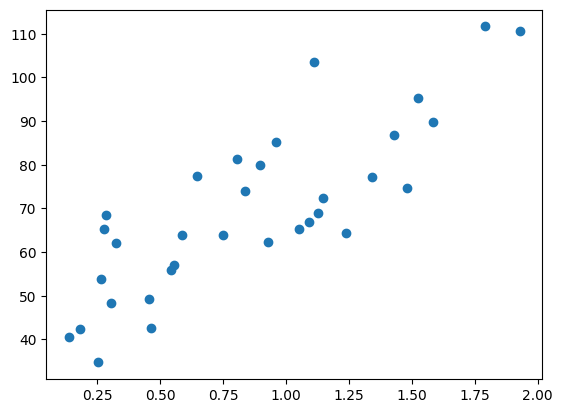

In [226]:
x = [grp_dict[grp]["log_num_gc"] for grp in grp_dict.keys()]
yh = [gal_dict[grp]["log_m_halo_sat"] for grp in grp_dict.keys()]
ys = [gal_dict[grp]["log_m_star_sat"] for grp in grp_dict.keys()]
yv = [gal_dict[grp]["vel_circ_max_sat"] for grp in grp_dict.keys()]

y = yv

plt.scatter(x, y)
stats.pearsonr(x, y)